In [1]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import date
import numpy as np
import datetime

pd.options.display.max_rows = 999
pd.options.display.max_columns = 999

In [2]:
df_k9 = pd.read_csv("../H3K9me3-zhuojie-regions/data/zhuojie_c1_avglogfc.csv")
df_k9 = df_k9.rename(columns={"avg_logFC": "logFC_k9"})
df_k9.shape

(91, 5)

In [3]:
df_k9.head(1)

,tissue,cell_type,logFC_k9,num_up_peaks,num_down_peaks
0,brainCB,brainCB-GC_ExN,-1.565036,2,273


In [4]:
!pwd

/storage/zhangyanxiaoLab/qihongjian/github/zhanglab-code/projects/paired_seq_tag/code/machine-experiments/analysis/H3K9me3/H3K9me3-gene-TE-corr


In [25]:

df_genes = pd.read_csv("../../../RNA/GSEA/data/gsea_per_celltype_results.csv")
df_genes["gene"] = df_genes["Description"]
df_genes["logFC"] = df_genes["NES"]
df_genes["FDR"] = df_genes["p.adjust"]

In [26]:
df_k9.head()
df_genes.head()

,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment,cell_type,gene,logFC,FDR
0,GO:0009060,aerobic respiration,135,0.567976,2.266421,2.312005e-10,0.000001,0.000001,2879,"tags=59%, list=25%, signal=44%",Cox7a1/Uqcr10/Uqcrh/Cox6a1/Cox7c/Trpv4/Chchd10...,BAT-ASPC,aerobic respiration,2.266421,0.000001
1,GO:0045333,cellular respiration,175,0.504708,2.086959,3.480287e-09,0.000007,0.000006,2879,"tags=53%, list=25%, signal=40%",Cox7a1/Uqcr10/Uqcrh/Cox6a1/Cox7c/Trpv4/Chchd10...,BAT-ASPC,cellular respiration,2.086959,0.000007
2,GO:0043062,extracellular structure organization,207,-0.498124,-2.062019,3.937187e-09,0.000007,0.000006,1455,"tags=34%, list=13%, signal=30%",Fkbp10/Dpp4/Crtap/Efemp2/Thsd4/Adamtsl1/Hspg2/...,BAT-ASPC,extracellular structure organization,-2.062019,0.000007
3,GO:0006986,response to unfolded protein,89,-0.615013,-2.263543,1.501168e-08,0.000011,0.000010,1784,"tags=44%, list=16%, signal=37%",Bag3/Tm7sf3/Thbs1/Derl1/Cdk5rap3/Edem2/Dnajc10...,BAT-ASPC,response to unfolded protein,-2.263543,0.000011
4,GO:0006119,oxidative phosphorylation,99,0.594573,2.257606,1.264033e-08,0.000011,0.000010,2879,"tags=65%, list=25%, signal=49%",Cox7a1/Uqcr10/Uqcrh/Cox6a1/Cox7c/Chchd10/Atp5o...,BAT-ASPC,oxidative phosphorylation,2.257606,0.000011


In [27]:
results = []

for gene, df_g in df_genes.groupby("gene"):
    df_m = (
        df_g
        .merge(df_k9, on=["cell_type"], how="inner")
        .dropna(subset=["logFC", "logFC_k9"])
    )

    # 至少需要 10 个点
    if df_m.shape[0] < 10:
        continue

    # Pearson
    r_p, p_p = pearsonr(df_m["logFC"], df_m["logFC_k9"])

    # Spearman
    r_s, p_s = spearmanr(df_m["logFC"], df_m["logFC_k9"])

    results.append({
        "gene": gene,
        "Description":df_g["Description"],
        "n_points": df_m.shape[0],
        "pearson_r": r_p,
        "pearson_p": p_p,
        "spearman_r": r_s,
        "spearman_p": p_s
    })



In [28]:

df_corr = pd.DataFrame(results)
df_corr["pearson_fdr"] = multipletests(df_corr["pearson_p"],  method="fdr_bh")[1]
df_corr["spearman_fdr"] = multipletests(df_corr["spearman_p"],  method="fdr_bh")[1]
df_corr = df_corr.sort_values("pearson_fdr")
df_corr.to_csv("data/H3K9me3_pathway_NES_corr.csv", index=False)
df_corr.shape

(5880, 9)

In [29]:
df_corr.head()

,gene,Description,n_points,pearson_r,pearson_p,spearman_r,spearman_p,pearson_fdr,spearman_fdr
381,antigen processing and presentation of peptide...,1800 antigen processing and presentation ...,90,-0.459793,0.000005,-0.544026,2.993592e-08,0.012767,0.000174
4278,regulation of axon regeneration,2882 regulation of axon regeneration 8151...,90,0.455314,0.000007,0.393028,1.271694e-04,0.012767,0.007808
374,antigen processing and presentation,462 antigen processing and presentation ...,91,-0.467558,0.000003,-0.531502,5.934200e-08,0.012767,0.000174
5438,secondary metabolic process,264 secondary metabolic process 9603 ...,89,-0.441821,0.000015,-0.450460,9.447372e-06,0.019371,0.002057
3611,positive regulation of pattern recognition rec...,2884 positive regulation of pattern recog...,91,-0.434924,0.000016,-0.411037,5.182649e-05,0.019371,0.005079


#### plot #####

In [30]:
pos_corr_f = df_corr[(df_corr['spearman_r'] > 0) & (df_corr['spearman_fdr'] < 0.05)]
neg_corr_f = df_corr[(df_corr['spearman_r'] < 0) & (df_corr['spearman_fdr'] < 0.05)]

# Order genes by spearman_fdr ascending (most significant first)
pos_genes_ordered = pos_corr_f.sort_values('spearman_fdr', ascending=True)['gene'].tolist()
neg_genes_ordered = neg_corr_f.sort_values('spearman_fdr', ascending=True)['gene'].tolist()

# Cell type order: low → high logFC_k9
ct_order = df_k9.sort_values('logFC_k9', ascending=True)['cell_type'].tolist()
logfc_k9_vals = df_k9.set_index('cell_type').loc[ct_order, 'logFC_k9'].values

# Build wide matrices
df_pos_wide = df_genes[df_genes['gene'].isin(pos_genes_ordered)].pivot_table(
    index='gene', columns='cell_type', values='logFC', aggfunc='mean'
).reindex(index=pos_genes_ordered, columns=ct_order)

df_neg_wide = df_genes[df_genes['gene'].isin(neg_genes_ordered)].pivot_table(
    index='gene', columns='cell_type', values='logFC', aggfunc='mean'
).reindex(index=neg_genes_ordered, columns=ct_order)

df_pos_sig = df_genes[df_genes['gene'].isin(pos_genes_ordered)].pivot_table(
    index='gene', columns='cell_type', values='FDR', aggfunc='mean'
).reindex(index=pos_genes_ordered, columns=ct_order)

df_neg_sig = df_genes[df_genes['gene'].isin(neg_genes_ordered)].pivot_table(
    index='gene', columns='cell_type', values='FDR', aggfunc='mean'
).reindex(index=neg_genes_ordered, columns=ct_order)

print(f"Pos: {len(pos_genes_ordered)} genes | Neg: {len(neg_genes_ordered)} genes")
print(f"Top 5 pos genes by FDR: {pos_genes_ordered[:5]}")
print(f"Top 5 neg genes by FDR: {neg_genes_ordered[:5]}")


Pos: 40 genes | Neg: 323 genes
Top 5 pos genes by FDR: ['phosphatidylcholine biosynthetic process', 'regulation of respiratory gaseous exchange', 'regulation of phospholipid metabolic process', 'regulation of axon regeneration', 'negative regulation of axon regeneration']
Top 5 neg genes by FDR: ['antigen processing and presentation of peptide antigen', 'antigen processing and presentation', 'T cell mediated immunity', 'leukocyte mediated cytotoxicity', 'regulation of leukocyte mediated cytotoxicity']


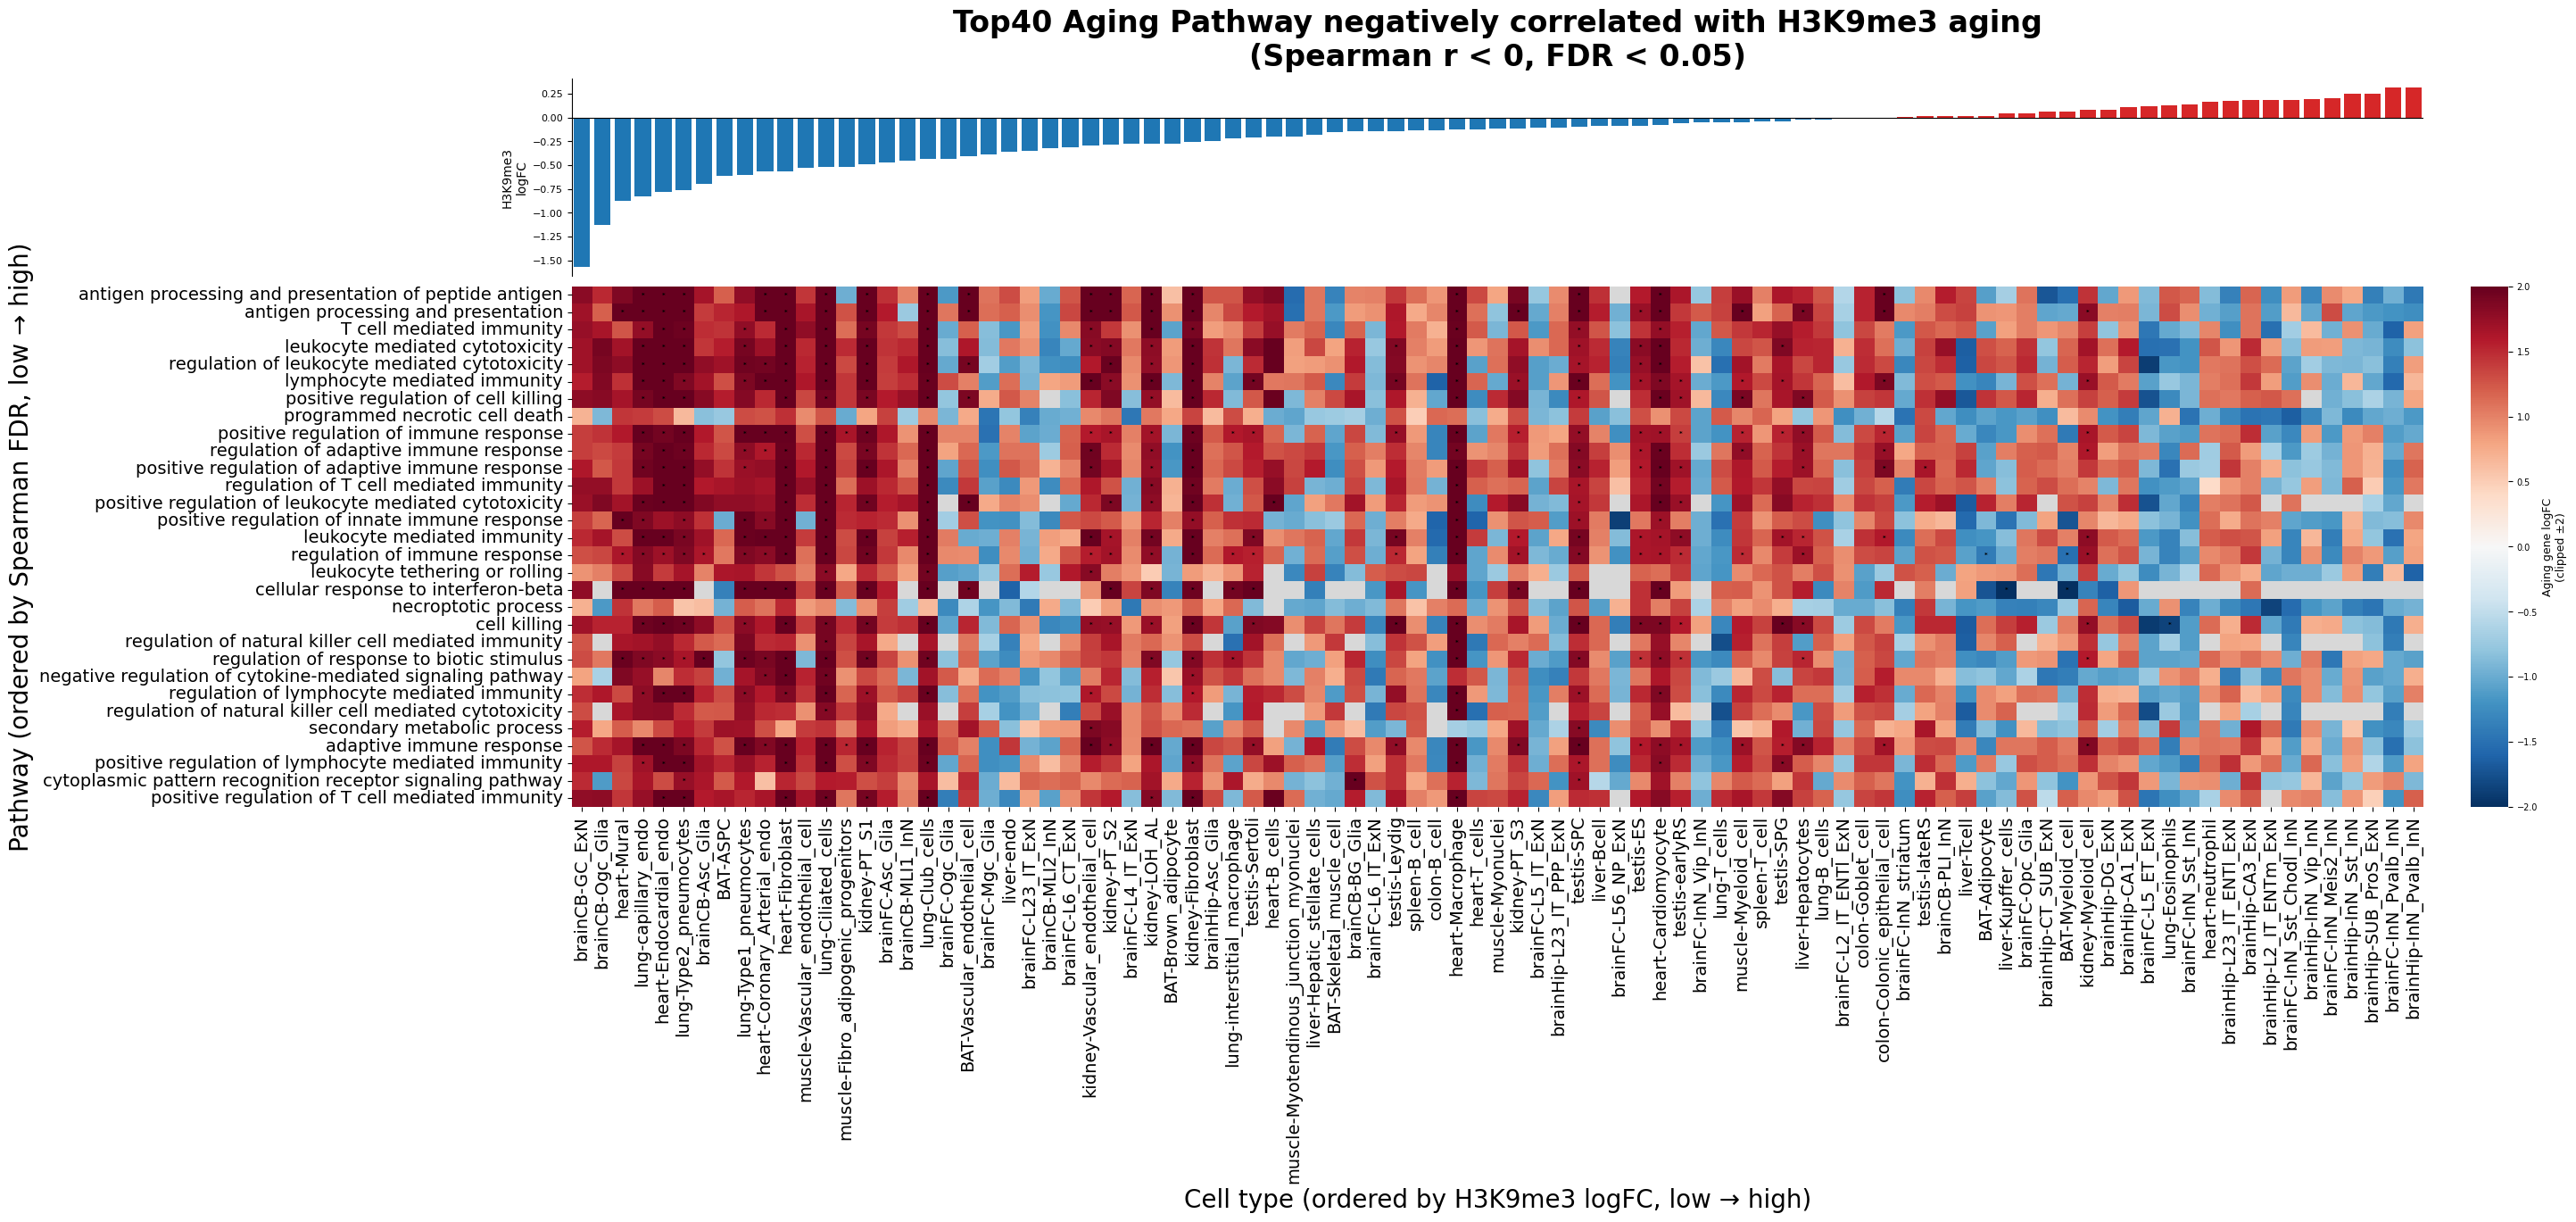

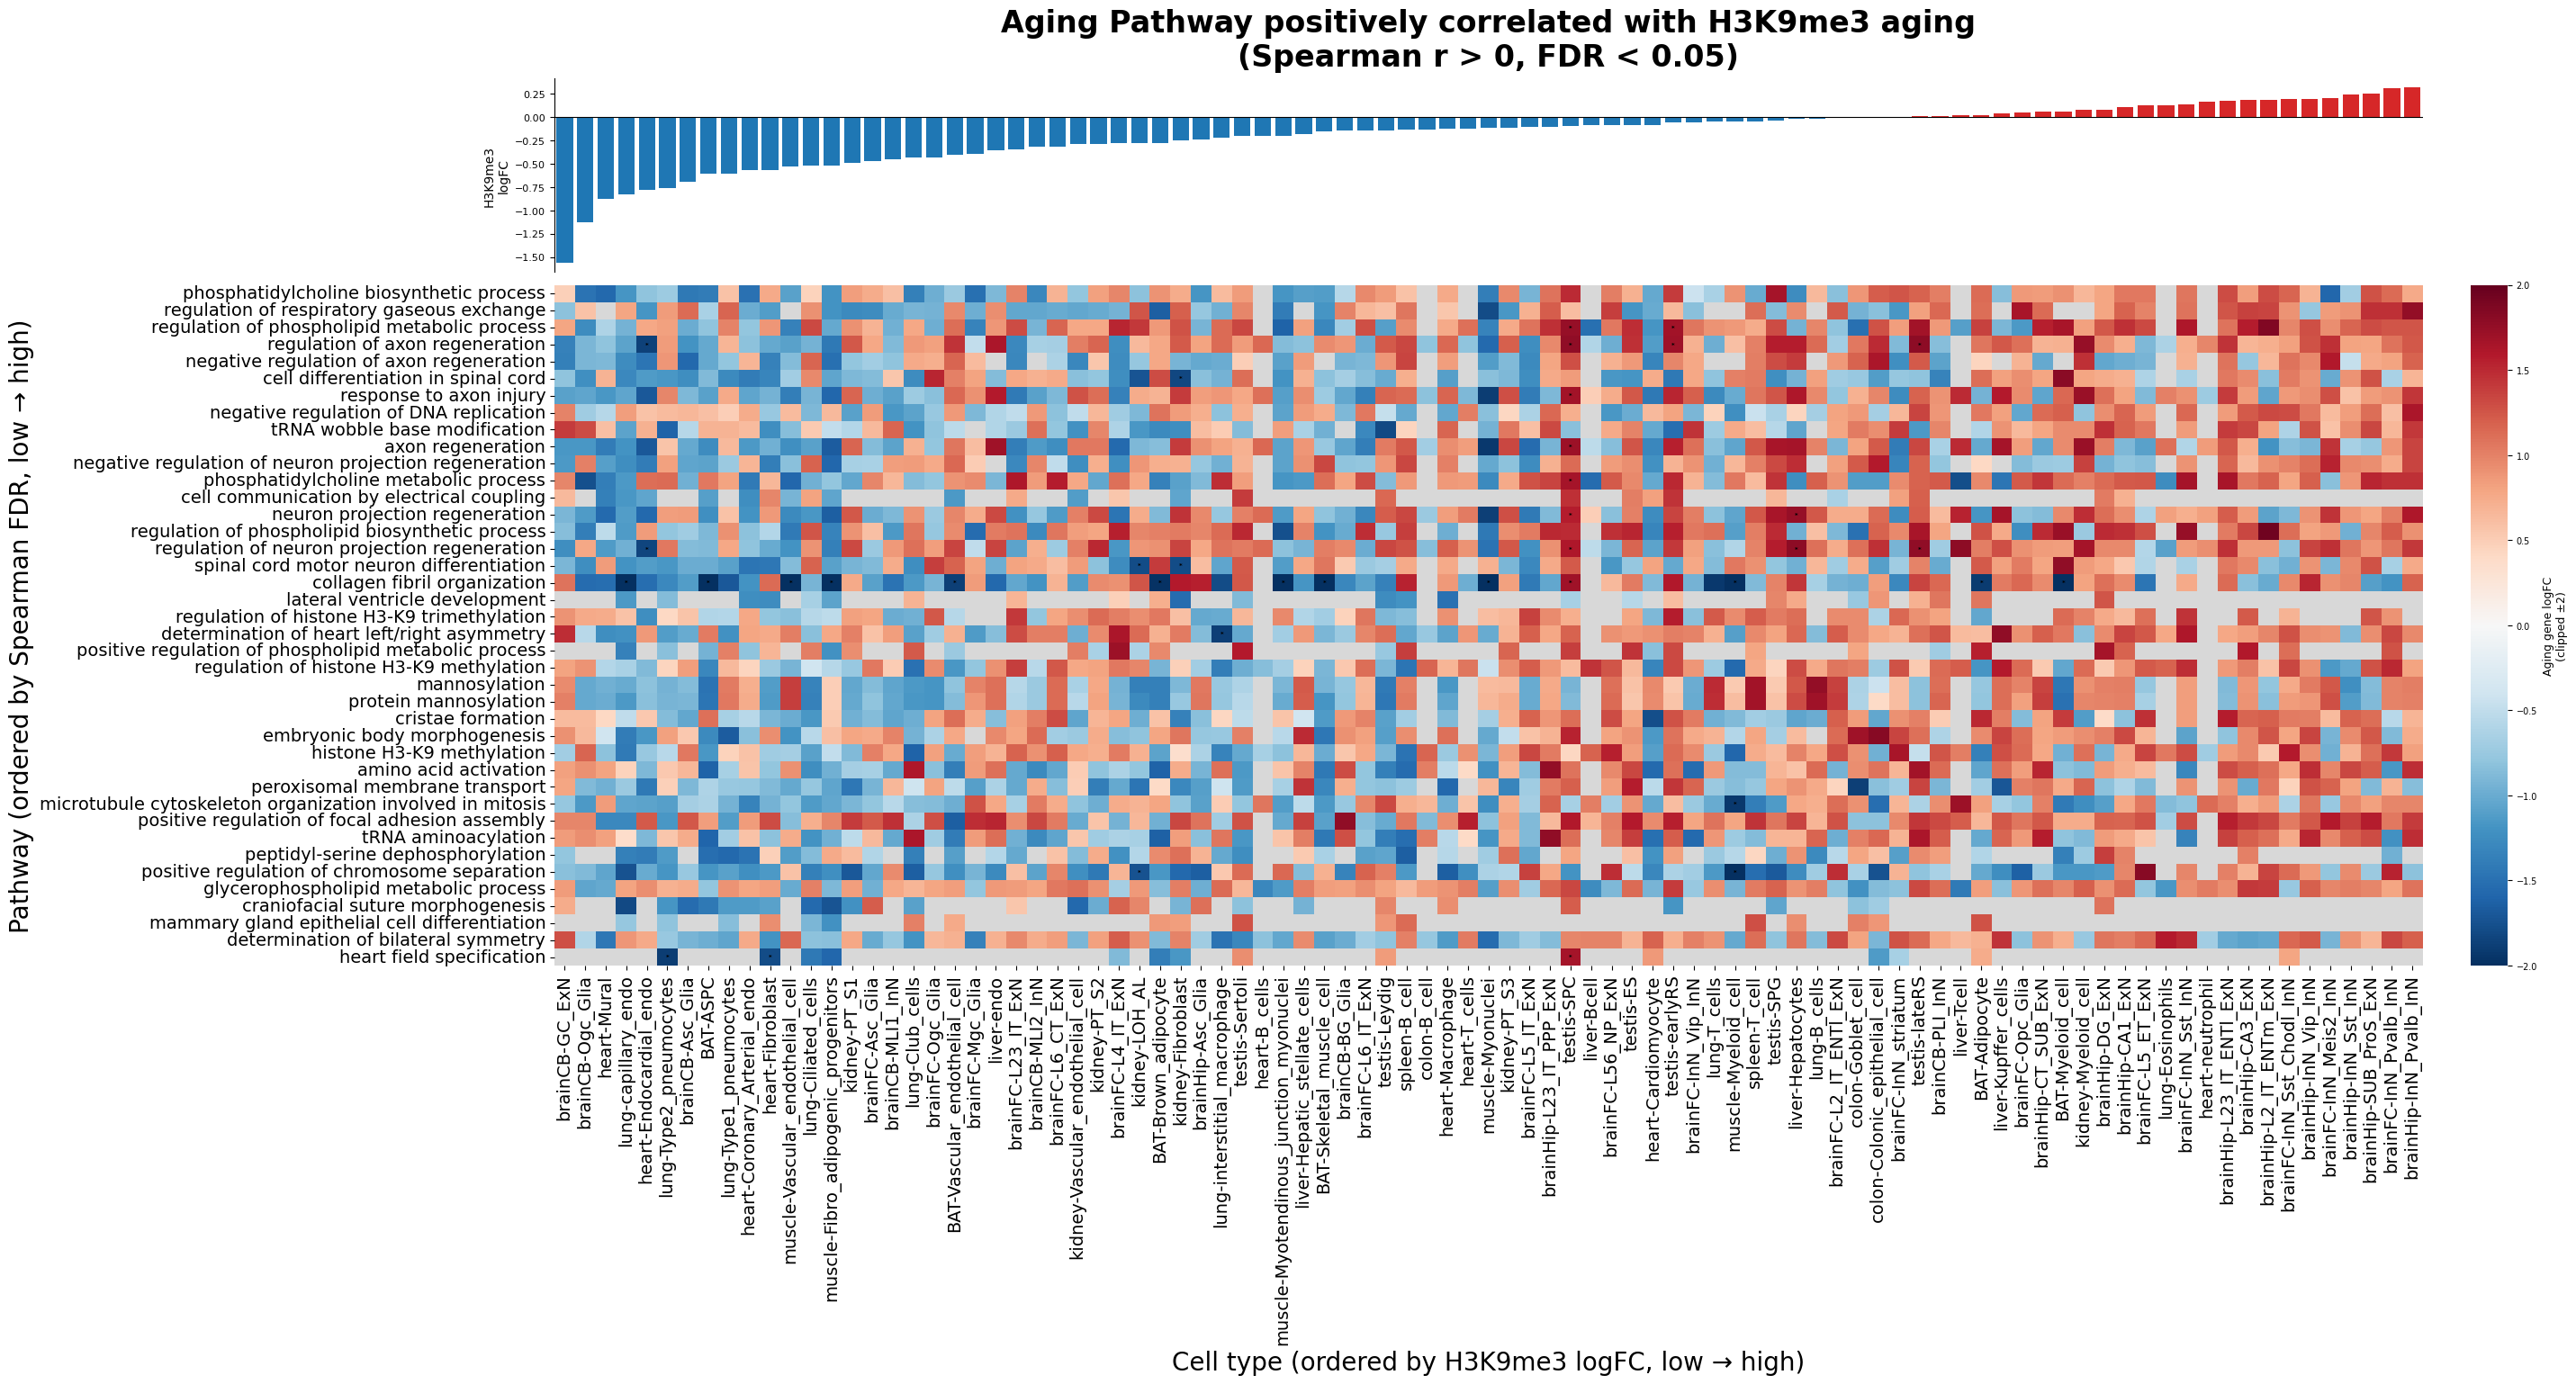

In [46]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

vmax = 2.0
bar_colors = ['#D62728' if v > 0 else '#1F77B4' for v in logfc_k9_vals]

def make_full_figure(wide_df, sig_df, genes_ordered, ct_order, logfc_k9_vals,
                     bar_colors, title, ylabel, row_height=0.22, star_fontsize=5):

    n_genes = len(genes_ordered)
    n_ct = len(ct_order)
    fig_height = max(10, n_genes * row_height + 4)

    fig = plt.figure(figsize=(28, fig_height))

    # ✅ 关键：2列 layout，右边给 colorbar
    gs = gridspec.GridSpec(
        2, 2,
        height_ratios=[2.5, n_genes * row_height],
        width_ratios=[50, 1],
        hspace=0.03,
        wspace=0.05
    )

    # ======================
    # 🔵 Bar plot（左上）
    # ======================
    ax_bar = fig.add_subplot(gs[0, 0])

    ax_bar.bar(range(n_ct), logfc_k9_vals,
               color=bar_colors, width=0.8, linewidth=0)

    ax_bar.axhline(0, color='black', linewidth=0.8)
    ax_bar.set_xlim(-0.5, n_ct - 0.5)

    ax_bar.set_xticks([])
    ax_bar.set_ylabel('H3K9me3\nlogFC', fontsize=10)
    ax_bar.tick_params(axis='y', labelsize=8)

    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)
    ax_bar.spines['bottom'].set_visible(False)

    ax_bar.set_title(title, fontsize=24, fontweight='bold', pad=10)

    # ======================
    # 🔴 Heatmap（左下）
    # ======================
    ax_heat = fig.add_subplot(gs[1, 0])

    # colorbar 单独轴
    cbar_ax = fig.add_subplot(gs[1, 1])

    mask = wide_df.isna()

    hm = sns.heatmap(
        wide_df.clip(-vmax, vmax),
        mask=mask,
        cmap='RdBu_r',
        center=0,
        vmin=-vmax,
        vmax=vmax,
        ax=ax_heat,
        linewidths=0,
        cbar=True,
        cbar_ax=cbar_ax,   # ✅ 关键
        xticklabels=True,
        yticklabels=True,
    )

    ax_heat.set_facecolor('#D8D8D8')

    # ======================
    # ⭐ 标注显著性
    # ======================
    for i, gene in enumerate(genes_ordered):
        for j, ct in enumerate(ct_order):
            if ct not in sig_df.columns:
                continue

            fdr_val = sig_df.loc[gene, ct]

            if not np.isnan(fdr_val) and fdr_val < 0.05:
                ax_heat.text(
                    j + 0.5, i + 0.5, '*',
                    ha='center', va='center',
                    fontsize=star_fontsize,
                    color='black',
                    fontweight='bold'
                )

    # ======================
    # 🔧 axis 设置
    # ======================
    ax_heat.set_xlabel(
        'Cell type (ordered by H3K9me3 logFC, low → high)',
        fontsize=20
    )
    ax_heat.set_ylabel(ylabel, fontsize=20)

    ax_heat.tick_params(axis='x', labelsize=14, rotation=90)
    ax_heat.tick_params(axis='y', labelsize=14, rotation=0)

    # ======================
    # 🎯 colorbar 美化
    # ======================
    cbar = hm.collections[0].colorbar
    cbar.set_label('Aging gene logFC\n(clipped ±2)', fontsize=9)
    cbar.ax.tick_params(labelsize=7)

    return fig



# ======================
# 🚀 Figure 2: Negative
# ======================

fig2 = make_full_figure(
    df_neg_wide.head(30),
    df_neg_sig,
    neg_genes_ordered[:30],
    ct_order,
    logfc_k9_vals,
    bar_colors,
    title='Top40 Aging Pathway negatively correlated with H3K9me3 aging\n(Spearman r < 0, FDR < 0.05)',
    ylabel='Pathway (ordered by Spearman FDR, low → high)',
)

fig2.show()

# ======================
# 🚀 Figure 1: Positive
# ======================

fig1 = make_full_figure(
    df_pos_wide,
    df_pos_sig,
    pos_genes_ordered,
    ct_order,
    logfc_k9_vals,
    bar_colors,
    title='Aging Pathway positively correlated with H3K9me3 aging\n(Spearman r > 0, FDR < 0.05)',
    ylabel='Pathway (ordered by Spearman FDR, low → high)',
)

fig1.show()

